In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [2]:
df = pd.read_csv('data-export (1).csv')

In [3]:
df.head()

,# ----------------------------------------,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5,Unnamed: 6,Unnamed: 7,Unnamed: 8,Unnamed: 9
0,Session primary channel group (Default channel...,Date + hour (YYYYMMDDHH),Users,Sessions,Engaged sessions,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
1,Direct,2024041623,237,300,144,47.526666666666700,0.6075949367088610,4.673333333333330,0.48,1402
2,Organic Social,2024041719,208,267,132,32.09737827715360,0.6346153846153850,4.295880149812730,0.4943820224719100,1147
3,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
4,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044


In [8]:
df.columns = df.iloc[0]
df = df.drop(index = 0).reset_index(drop=True)
df.columns = ["channel group" , "DateHour" , "Users" , "Sessions" , "Engaged Session" , "Average engagement time per session" ,	"Engaged sessions per user" , "Events per session",	"Engagement rate" ,	"Event count"]

In [9]:
df.head()

,channel group,DateHour,Users,Sessions,Engaged Session,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count
0,Direct,2024041723,188,233,115,39.93991416309010,0.6117021276595740,4.587982832618030,0.49356223175965700,1069
1,Organic Social,2024041718,187,256,125,32.16015625,0.6684491978609630,4.078125,0.48828125,1044
2,Organic Social,2024041720,175,221,112,46.918552036199100,0.64,4.529411764705880,0.5067873303167420,1001
3,Organic Social,2024041721,160,206,103,59.31553398058250,0.64375,4.694174757281550,0.5,967
4,Organic Social,2024050119,160,219,110,40.31506849315070,0.6875,4.63013698630137,0.502283105022831,1014


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3180 entries, 0 to 3179
Data columns (total 10 columns):
 #   Column                               Non-Null Count  Dtype 
---  ------                               --------------  ----- 
 0   channel group                        3180 non-null   object
 1   DateHour                             3180 non-null   object
 2   Users                                3180 non-null   object
 3   Sessions                             3180 non-null   object
 4   Engaged Session                      3180 non-null   object
 5   Average engagement time per session  3180 non-null   object
 6   Engaged sessions per user            3180 non-null   object
 7   Events per session                   3180 non-null   object
 8   Engagement rate                      3180 non-null   object
 9   Event count                          3180 non-null   object
dtypes: object(10)
memory usage: 248.6+ KB


In [17]:
df["DateHour"] = pd.to_datetime(df["DateHour"] , format = "%y%m%d%h" , errors = 'coerce')

In [20]:
numeric_cols = df.columns.drop(["channel group" , "DateHour"])
df[numeric_cols] =df[numeric_cols].apply(pd.to_numeric , errors = 'coerce')
df["Hour"] = df["DateHour"].dt.hour

In [22]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3180 entries, 0 to 3179
Data columns (total 11 columns):
 #   Column                               Non-Null Count  Dtype         
---  ------                               --------------  -----         
 0   channel group                        3180 non-null   object        
 1   DateHour                             3180 non-null   datetime64[ns]
 2   Users                                3180 non-null   int64         
 3   Sessions                             3180 non-null   int64         
 4   Engaged Session                      3180 non-null   int64         
 5   Average engagement time per session  3180 non-null   float64       
 6   Engaged sessions per user            3180 non-null   float64       
 7   Events per session                   3180 non-null   float64       
 8   Engagement rate                      3180 non-null   float64       
 9   Event count                          3180 non-null   int64         
 10  Hour        

,channel group,DateHour,Users,Sessions,Engaged Session,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
0,Direct,2024-04-17 23:00:00,188,233,115,39.939914,0.611702,4.587983,0.493562,1069,23
1,Organic Social,2024-04-17 18:00:00,187,256,125,32.160156,0.668449,4.078125,0.488281,1044,18
2,Organic Social,2024-04-17 20:00:00,175,221,112,46.918552,0.640000,4.529412,0.506787,1001,20
3,Organic Social,2024-04-17 21:00:00,160,206,103,59.315534,0.643750,4.694175,0.500000,967,21
4,Organic Social,2024-05-01 19:00:00,160,219,110,40.315068,0.687500,4.630137,0.502283,1014,19


In [23]:
df.describe()

,DateHour,Users,Sessions,Engaged Session,Average engagement time per session,Engaged sessions per user,Events per session,Engagement rate,Event count,Hour
count,3180,3180.000000,3180.000000,3180.000000,3180.000000,3180.000000,3180.000000,3180.000000,3180.000000,3180.000000
mean,2024-04-20 01:19:32.830188800,41.822327,51.046541,28.256604,66.661457,0.606440,4.676089,0.503406,241.623270,11.801258
min,2024-04-06 00:00:00,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
25%,2024-04-13 02:00:00,20.000000,24.000000,13.000000,32.105625,0.561404,3.750000,0.442857,103.000000,6.000000
50%,2024-04-20 02:30:00,42.000000,51.000000,27.000000,49.068279,0.666667,4.410256,0.545455,226.000000,12.000000
75%,2024-04-26 22:00:00,60.000000,71.000000,41.000000,71.509259,0.750000,5.218581,0.633333,339.000000,18.000000
max,2024-05-03 23:00:00,188.000000,256.000000,125.000000,4525.000000,2.000000,56.000000,1.000000,1117.000000,23.000000
std,NaN,29.240446,36.466375,20.472406,127.238737,0.264105,2.796099,0.228277,182.643504,6.884807


# sessions and user ove time

In [24]:
sns.set(style = "whitegrid")

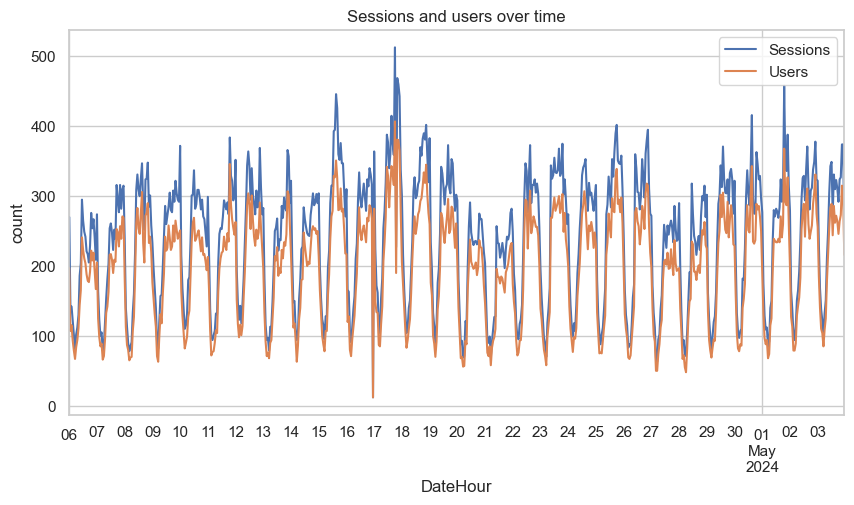

In [28]:
plt.figure(figsize=(10 , 5))
df.groupby("DateHour")[["Sessions" , "Users"]].sum().plot(ax=plt.gca())
plt.title("Sessions and users over time")
plt.xlabel("DateHour")
plt.ylabel("count")
plt.show()

# Total users by channel

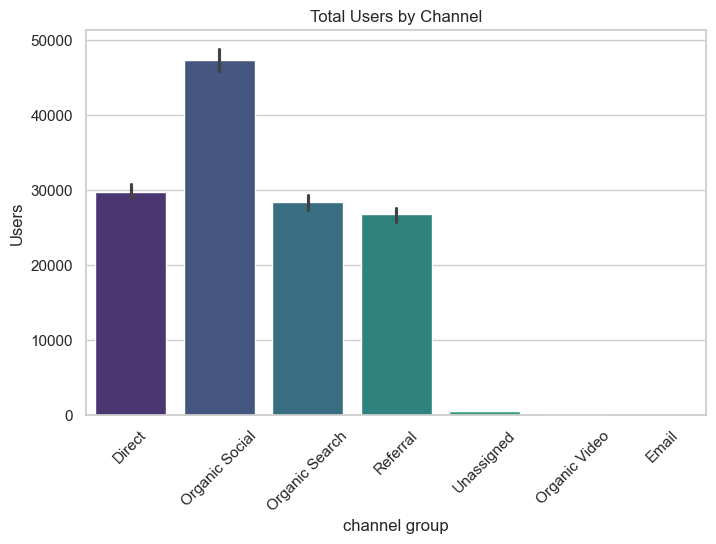

In [43]:
plt.figure(figsize= (8,5))
sns.barplot(data = df , x ="channel group" , y = "Users", hue ="channel group" ,estimator=np.sum , palette = "viridis")
plt.title("Total Users by Channel")
plt.xticks(rotation=45)
plt.show()

# Average engagement time by channel

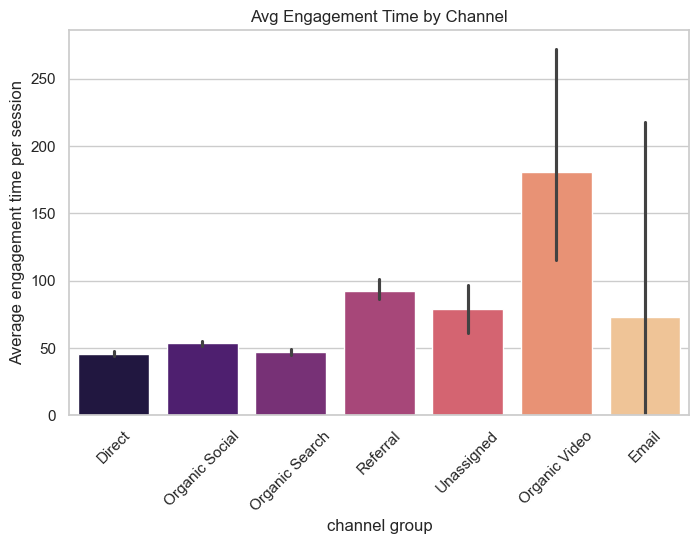

In [53]:
plt.figure(figsize = (8,5))
sns.barplot(data = df , x ="channel group" , y ="Average engagement time per session" , estimator=np.mean , hue="channel group" ,palette ="magma")
plt.title("Avg Engagement Time by Channel")
plt.xticks(rotation = 45)
plt.show()

# Engagement Rate Distribution by Channel

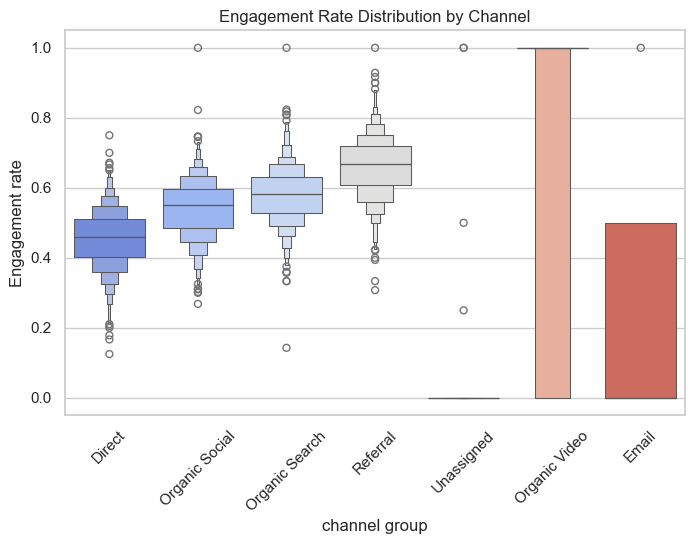

In [51]:
plt.figure(figsize=(8,5))
sns.boxenplot(data = df , x= "channel group" , y = "Engagement rate" ,hue="channel group", palette = "coolwarm")
plt.title("Engagement Rate Distribution by Channel")
plt.xticks(rotation = 45)
plt.show()

# Engaged vs Non Engaged Session

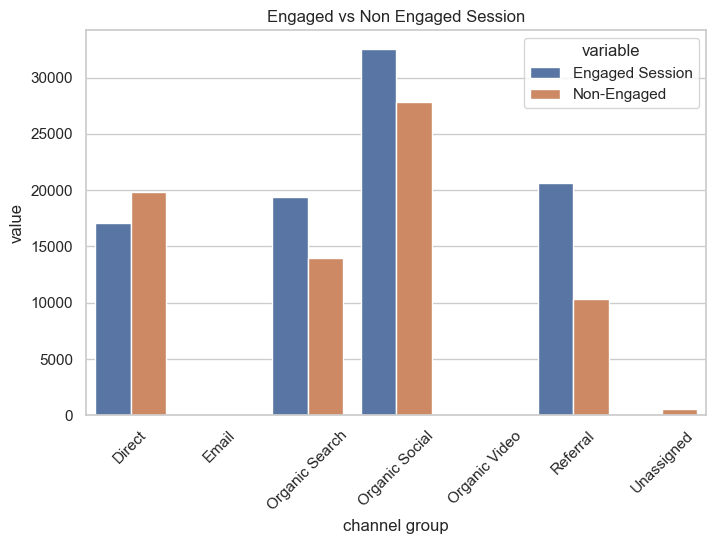

In [64]:
session_df = df.groupby("channel group")[["Sessions" , "Engaged Session" ]].sum().reset_index()
session_df["Non-Engaged"] = session_df["Sessions"] - session_df["Engaged Session"]
session_df_melted = session_df.melt(id_vars="channel group" ,  value_vars =["Engaged Session" , "Non-Engaged"] )
plt.figure(figsize=(8,5))
sns.barplot(data = session_df_melted , x ="channel group" , y ="value" , hue="variable")
plt.title("Engaged vs Non Engaged Session")
plt.xticks(rotation=45)
plt.show()

# Traffic by hour and channel

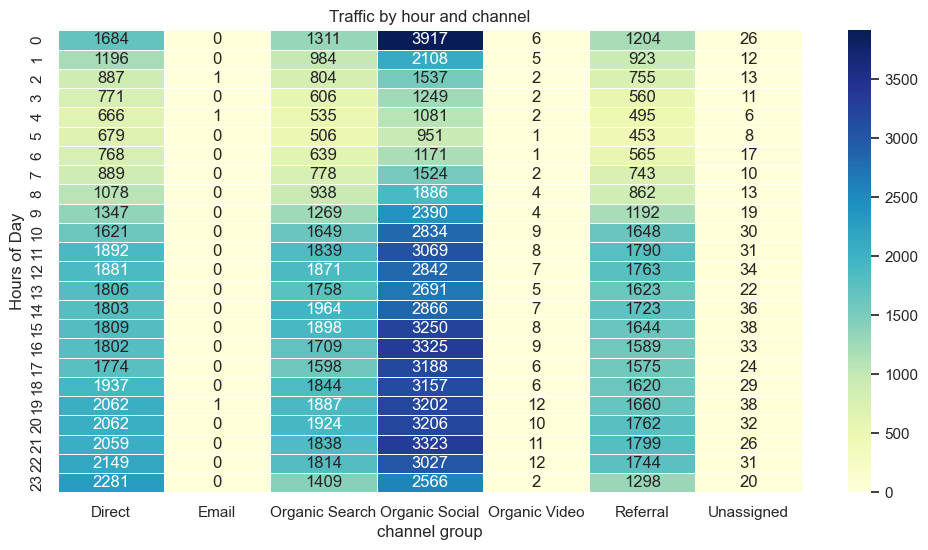

In [74]:
heatmap_data = df.groupby(["Hour" , "channel group"])["Sessions"].sum().unstack().fillna(0)
plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data , cmap="YlGnBu" , linewidth =.5 , annot = True , fmt ='.0f')
plt.title("Traffic by hour and channel")
plt.ylabel("Hours of Day")
plt.show()

# Engagement rate vs sessions over time

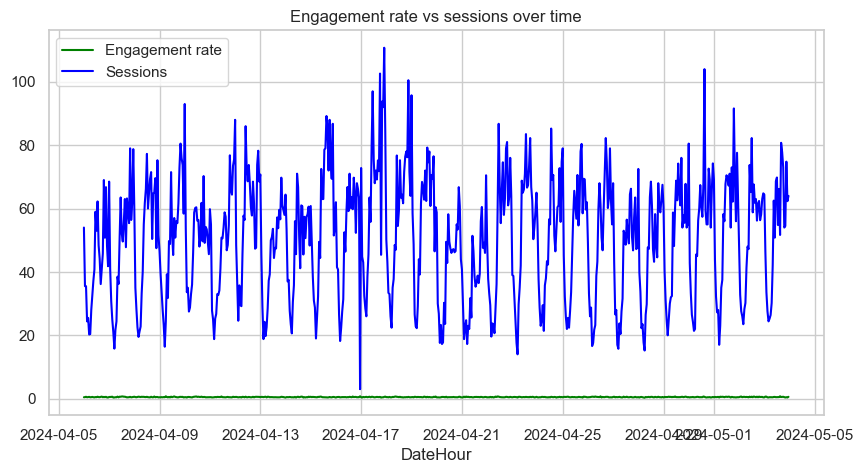

In [86]:
df_plot = df.groupby("DateHour")[["Sessions" , "Engagement rate"]].mean().reset_index()
plt.figure(figsize=(10 , 5))
plt.plot(df_plot["DateHour"] , df_plot["Engagement rate"] , label = "Engagement rate", color = "green")
plt.plot(df_plot["DateHour"] , df_plot["Sessions"] , label = "Sessions", color = "blue")
plt.title("Engagement rate vs sessions over time")
plt.xlabel("DateHour")
plt.legend()
plt.grid(True)
plt.show()